In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model = 'gpt-5-nano')

In [8]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

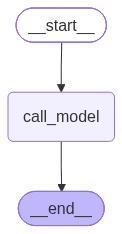

In [12]:
graph = builder.compile()
graph

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi!, My name is Dhanraj."}]})

{'messages': [HumanMessage(content='Hi!, My name is Dhanraj.', additional_kwargs={}, response_metadata={}, id='1d369455-cc0d-4b9c-a578-9507542bd621'),
  AIMessage(content='Nice to meet you, Dhanraj! How can I help today? If you have a project, question, or topic in mind (writing, coding, study help, planning, brainstorming, etc.), tell me a bit more and I’ll tailor my assistance.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 318, 'prompt_tokens': 15, 'total_tokens': 333, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EFQFWqbiccLbgORRtgxFOvtNG4Lf1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02609-1fde

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "what is my name?"}]})

{'messages': [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='1ff47114-2de3-4c17-b1fd-765f34b5a4ee'),
  AIMessage(content='I don’t know your name yet. If you tell me your name or give me a nickname, I’ll use that in this conversation. If you’d rather not share, I can just call you “Friend,” “User,” or whatever you prefer. You choose.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 639, 'prompt_tokens': 11, 'total_tokens': 650, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EFQG9mno9TczWnhfe3pJRSV6InsFn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02609-a84c-7212-

In [15]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [18]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [19]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer = checkpointer)

In [20]:
config = {"configurable": {"thread_id": "thread-1"}}

In [21]:
graph.invoke({'messages': [{"role": "user", "content":"Hi! My name is Nitish"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish', additional_kwargs={}, response_metadata={}, id='cc4167f3-8238-4cfd-a16b-c0582b01f815'),
  AIMessage(content='Hi Nitish! Nice to meet you. How can I help today? Tell me what you’re working on or curious about, and I’ll tailor my help. Some quick ideas:\n- Explain a topic or concept\n- Help with writing, editing, or brainstorming\n- Debug code or review algorithms\n- Plan a project, study schedule, or trip\n- Translate something or practice a language\n\nWhat would you like to start with?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 609, 'prompt_tokens': 13, 'total_tokens': 622, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 512, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'sy

In [22]:
graph.invoke({'messages': [{"role": "user", "content":"What is my name"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish', additional_kwargs={}, response_metadata={}, id='cc4167f3-8238-4cfd-a16b-c0582b01f815'),
  AIMessage(content='Hi Nitish! Nice to meet you. How can I help today? Tell me what you’re working on or curious about, and I’ll tailor my help. Some quick ideas:\n- Explain a topic or concept\n- Help with writing, editing, or brainstorming\n- Debug code or review algorithms\n- Plan a project, study schedule, or trip\n- Translate something or practice a language\n\nWhat would you like to start with?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 609, 'prompt_tokens': 13, 'total_tokens': 622, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 512, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'sy

In [23]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
    print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Nitish
- AIMessage : Hi Nitish! Nice to meet you. How can I help today? Tell me what you’re working on or curious about, and I’ll tailor my help. Some quick ideas:
- Explain a topic or concept
- Help with writing, editing, or brainstorming
- Debug code or review algorithms
- Plan a project, study schedule, or trip
- Translate something or practice a language

What would you like to start with?
- HumanMessage : What is my name
- AIMessage : Your name is Nitish. Would you like me to remember it for this chat so I can address you correctly?
